# Thresholded weighted-degree effect-size maps

Create one Hedges' g NIfTI map per similarity percentile and plot them on a shared color scale.

In [1]:
from pathlib import Path
import os

from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    folder for folder in (Path.cwd(), *Path.cwd().parents)
    if (folder / "data" / "reference" / "MNI152_T1_1mm.nii.gz").is_file()
)
ROI_ROOT = PROJECT_ROOT / "outputs" / "rois"
STATISTICS_ROOT = PROJECT_ROOT / "outputs" / "statistics_thresholded_weighted_degree"
TEMPLATE_PATH = PROJECT_ROOT / "data" / "reference" / "MNI152_T1_1mm.nii.gz"
PERCENTILES = (10, 20, 40, 80)
N_JOBS = min(16, max(1, int((os.cpu_count() or 1) * 0.75)))

template_img = nib.load(TEMPLATE_PATH)
effect_by_percentile = {}
parcel_ids = None
table_summary = []

for percentile in PERCENTILES:
    results_path = (
        STATISTICS_ROOT
        / f"percentile_{percentile:02d}"
        / "thresholded_weighted_degree_independent_welch_tests.csv"
    )
    results = pd.read_csv(results_path)
    required = {"parcel_id", "hedges_g"}
    if not required.issubset(results.columns):
        raise ValueError(f"Missing required columns in {results_path}")
    if results["parcel_id"].duplicated().any():
        raise ValueError(f"Duplicate parcel IDs in {results_path}")

    current_parcel_ids = results["parcel_id"].tolist()
    if parcel_ids is None:
        parcel_ids = current_parcel_ids
    elif current_parcel_ids != parcel_ids:
        raise ValueError(f"Parcel order differs in {results_path}")

    effect_by_percentile[percentile] = dict(
        zip(results["parcel_id"], results["hedges_g"])
    )
    table_summary.append({
        "percentile": percentile,
        "parcels": len(results),
        "finite_effects": int(np.isfinite(results["hedges_g"]).sum()),
    })

display(pd.DataFrame(table_summary))
print(f"Using {N_JOBS} worker processes.")

,percentile,parcels,finite_effects
0,10,83442,83442
1,20,83442,83442
2,40,83442,83442
3,80,83442,83442


Using 16 worker processes.


In [2]:
def load_mask_voxels(roi_path, parcel_id, template_shape, template_affine):
    mask_img = nib.load(roi_path)
    if mask_img.shape != template_shape or not np.allclose(
        mask_img.affine, template_affine
    ):
        raise ValueError(f"Mask is not aligned to template: {roi_path}")
    return parcel_id, np.flatnonzero(np.asanyarray(mask_img.dataobj))

expected_parcels = set(parcel_ids)
roi_records = []
found_parcels = set()
label_dirs = [path for path in ROI_ROOT.iterdir() if path.is_dir() and path.name.isdigit()]
for label_dir in sorted(label_dirs, key=lambda path: int(path.name)):
    for roi_path in sorted(label_dir.glob("roi_*.nii.gz")):
        roi_index = roi_path.name.removeprefix("roi_").removesuffix(".nii.gz")
        parcel_id = f"label_{label_dir.name}/roi_{roi_index}"
        if parcel_id in expected_parcels:
            roi_records.append((str(roi_path), parcel_id))
            found_parcels.add(parcel_id)

missing_parcels = expected_parcels - found_parcels
if missing_parcels:
    raise ValueError(f"Missing ROI masks for {len(missing_parcels)} parcels")

effect_maps = {
    percentile: np.zeros(template_img.shape, dtype=np.float32)
    for percentile in PERCENTILES
}
flat_maps = {percentile: data.ravel() for percentile, data in effect_maps.items()}

loaded_masks = Parallel(
    n_jobs=N_JOBS,
    prefer="processes",
    batch_size=256,
    return_as="generator",
)(
    delayed(load_mask_voxels)(
        roi_path, parcel_id, template_img.shape, template_img.affine
    )
    for roi_path, parcel_id in roi_records
)

for completed, (parcel_id, flat_voxels) in enumerate(loaded_masks, start=1):
    for percentile in PERCENTILES:
        effect_size = effect_by_percentile[percentile][parcel_id]
        if np.isfinite(effect_size):
            flat_maps[percentile][flat_voxels] = effect_size
    if completed % 1000 == 0 or completed == len(roi_records):
        print(f"Loaded {completed:,}/{len(roi_records):,} masks", flush=True)

Loaded 1,000/83,442 masks
Loaded 2,000/83,442 masks
Loaded 3,000/83,442 masks
Loaded 4,000/83,442 masks
Loaded 5,000/83,442 masks
Loaded 6,000/83,442 masks
Loaded 7,000/83,442 masks
Loaded 8,000/83,442 masks
Loaded 9,000/83,442 masks
Loaded 10,000/83,442 masks
Loaded 11,000/83,442 masks
Loaded 12,000/83,442 masks
Loaded 13,000/83,442 masks
Loaded 14,000/83,442 masks
Loaded 15,000/83,442 masks
Loaded 16,000/83,442 masks
Loaded 17,000/83,442 masks
Loaded 18,000/83,442 masks
Loaded 19,000/83,442 masks
Loaded 20,000/83,442 masks
Loaded 21,000/83,442 masks
Loaded 22,000/83,442 masks
Loaded 23,000/83,442 masks
Loaded 24,000/83,442 masks
Loaded 25,000/83,442 masks
Loaded 26,000/83,442 masks
Loaded 27,000/83,442 masks
Loaded 28,000/83,442 masks
Loaded 29,000/83,442 masks
Loaded 30,000/83,442 masks
Loaded 31,000/83,442 masks
Loaded 32,000/83,442 masks
Loaded 33,000/83,442 masks
Loaded 34,000/83,442 masks
Loaded 35,000/83,442 masks
Loaded 36,000/83,442 masks
Loaded 37,000/83,442 masks
Loaded 38,

In [3]:
map_paths = {}
for percentile in PERCENTILES:
    output_dir = STATISTICS_ROOT / f"percentile_{percentile:02d}"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / "thresholded_weighted_degree_hedges_g_map.nii.gz"

    header = template_img.header.copy()
    header.set_data_dtype(np.float32)
    effect_img = nib.Nifti1Image(
        effect_maps[percentile], template_img.affine, header
    )
    nib.save(effect_img, output_path)
    map_paths[percentile] = output_path
    print(f"Saved percentile {percentile}: {output_path}")

map_paths

Saved percentile 10: /home/lucagalli/Projects/parcellating_dbm/outputs/statistics_thresholded_weighted_degree/percentile_10/thresholded_weighted_degree_hedges_g_map.nii.gz
Saved percentile 20: /home/lucagalli/Projects/parcellating_dbm/outputs/statistics_thresholded_weighted_degree/percentile_20/thresholded_weighted_degree_hedges_g_map.nii.gz
Saved percentile 40: /home/lucagalli/Projects/parcellating_dbm/outputs/statistics_thresholded_weighted_degree/percentile_40/thresholded_weighted_degree_hedges_g_map.nii.gz
Saved percentile 80: /home/lucagalli/Projects/parcellating_dbm/outputs/statistics_thresholded_weighted_degree/percentile_80/thresholded_weighted_degree_hedges_g_map.nii.gz


{10: PosixPath('/home/lucagalli/Projects/parcellating_dbm/outputs/statistics_thresholded_weighted_degree/percentile_10/thresholded_weighted_degree_hedges_g_map.nii.gz'),
 20: PosixPath('/home/lucagalli/Projects/parcellating_dbm/outputs/statistics_thresholded_weighted_degree/percentile_20/thresholded_weighted_degree_hedges_g_map.nii.gz'),
 40: PosixPath('/home/lucagalli/Projects/parcellating_dbm/outputs/statistics_thresholded_weighted_degree/percentile_40/thresholded_weighted_degree_hedges_g_map.nii.gz'),
 80: PosixPath('/home/lucagalli/Projects/parcellating_dbm/outputs/statistics_thresholded_weighted_degree/percentile_80/thresholded_weighted_degree_hedges_g_map.nii.gz')}

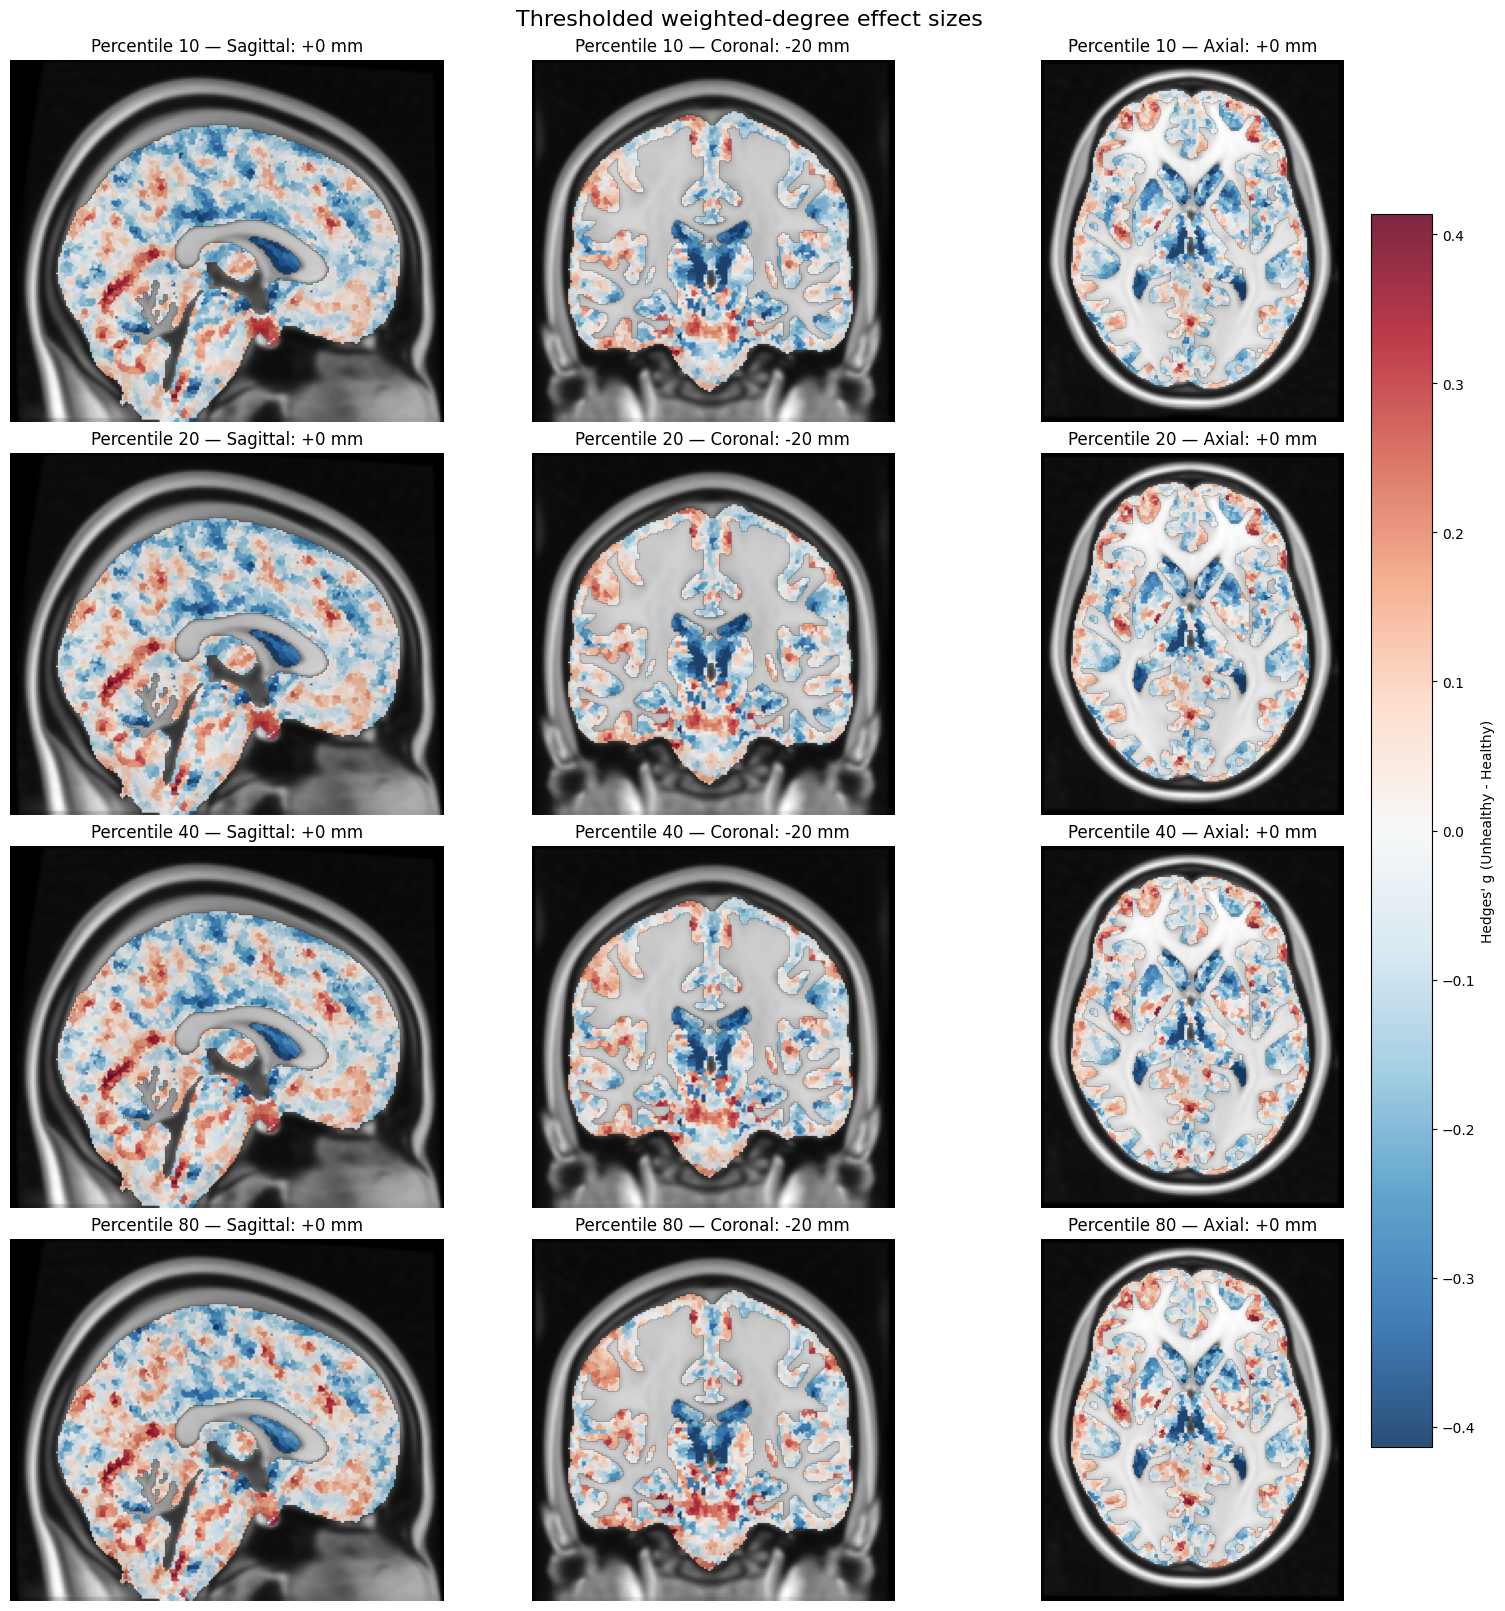

Saved figure: /home/lucagalli/Projects/parcellating_dbm/outputs/statistics_thresholded_weighted_degree/thresholded_weighted_degree_hedges_g_maps.png


In [4]:
template_data = template_img.get_fdata(dtype=np.float32)
nonzero_effects = np.concatenate([
    np.abs(data[np.isfinite(data) & (data != 0)])
    for data in effect_maps.values()
])
if nonzero_effects.size == 0:
    raise ValueError("All effect-size maps are empty")
vmax = float(np.quantile(nonzero_effects, 0.99))

views = (
    (0, 0, "Sagittal"),
    (1, -20, "Coronal"),
    (2, 0, "Axial"),
)

def slice_at_mni(data, axis, coordinate):
    mni_coordinate = [0, 0, 0]
    mni_coordinate[axis] = coordinate
    voxel = int(np.rint(nib.affines.apply_affine(
        np.linalg.inv(template_img.affine), mni_coordinate
    )[axis]))
    voxel = np.clip(voxel, 0, template_img.shape[axis] - 1)
    if axis == 0:
        return data[voxel, :, :].T
    if axis == 1:
        return data[:, voxel, :].T
    return data[:, :, voxel].T

fig, panels = plt.subplots(
    len(PERCENTILES), len(views),
    figsize=(15, 4 * len(PERCENTILES)),
    constrained_layout=True,
)
image = None
for row, percentile in enumerate(PERCENTILES):
    for column, (axis, coordinate, view_name) in enumerate(views):
        panel = panels[row, column]
        background = slice_at_mni(template_data, axis, coordinate)
        overlay = slice_at_mni(effect_maps[percentile], axis, coordinate)
        panel.imshow(background, cmap="gray", origin="lower")
        image = panel.imshow(
            np.ma.masked_where(~np.isfinite(overlay) | (overlay == 0), overlay),
            cmap="RdBu_r",
            vmin=-vmax,
            vmax=vmax,
            origin="lower",
            alpha=0.85,
        )
        panel.set_title(
            f"Percentile {percentile} — {view_name}: {coordinate:+d} mm"
        )
        panel.axis("off")

colorbar = fig.colorbar(image, ax=panels, shrink=0.8, pad=0.02)
colorbar.set_label("Hedges' g (Unhealthy - Healthy)")
fig.suptitle("Thresholded weighted-degree effect sizes", fontsize=16)
figure_path = STATISTICS_ROOT / "thresholded_weighted_degree_hedges_g_maps.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure: {figure_path}")